In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [42]:
df= pd.read_csv("/content/drive/MyDrive/machine learning dataset/titanic.csv")

In [43]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [44]:
df.shape

(418, 12)

In [45]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    elif df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].mean())
df.drop_duplicates(inplace=True)

In [46]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [47]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [48]:
df.shape

(418, 12)

In [49]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [50]:
auto=df[['PassengerId', 'Survived', 'Pclass', 'Name', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin']]

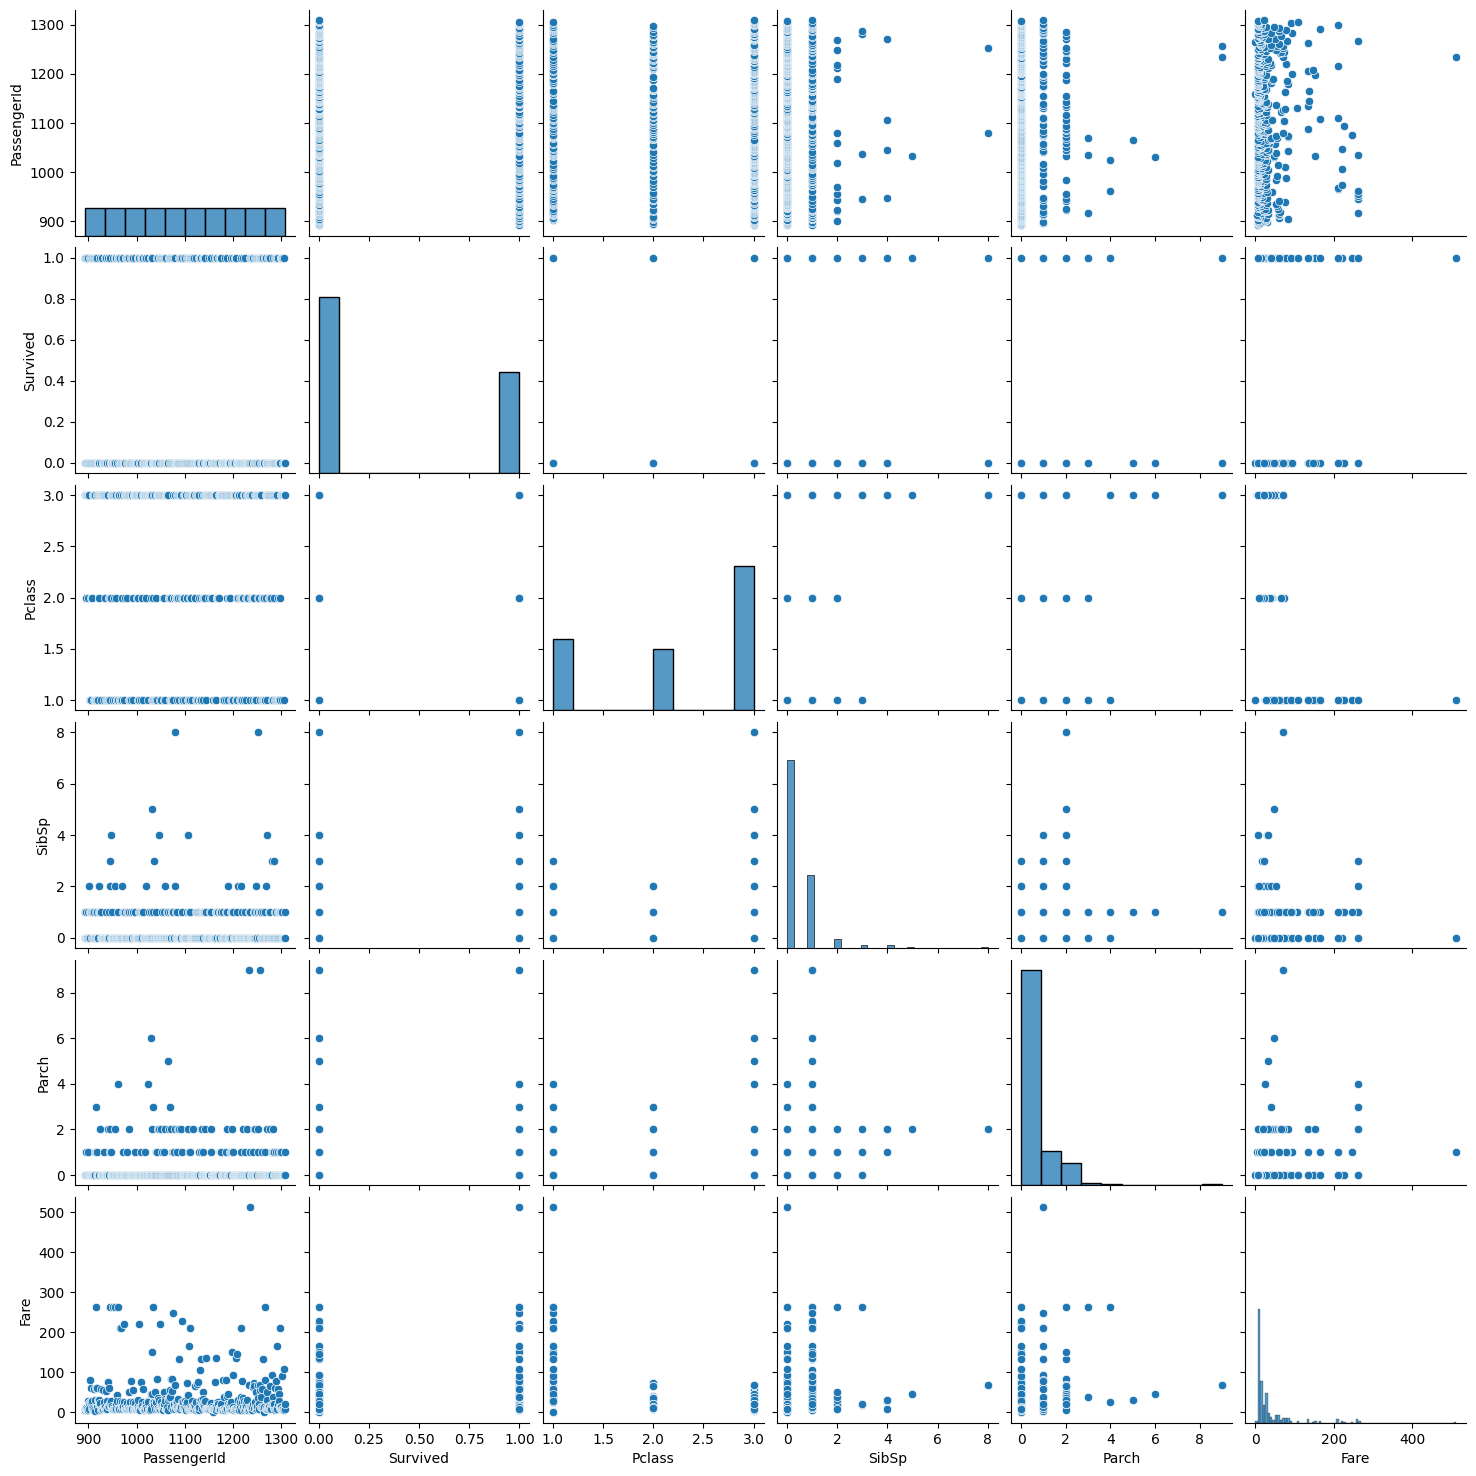

In [51]:

sns.pairplot(auto)

<Axes: >

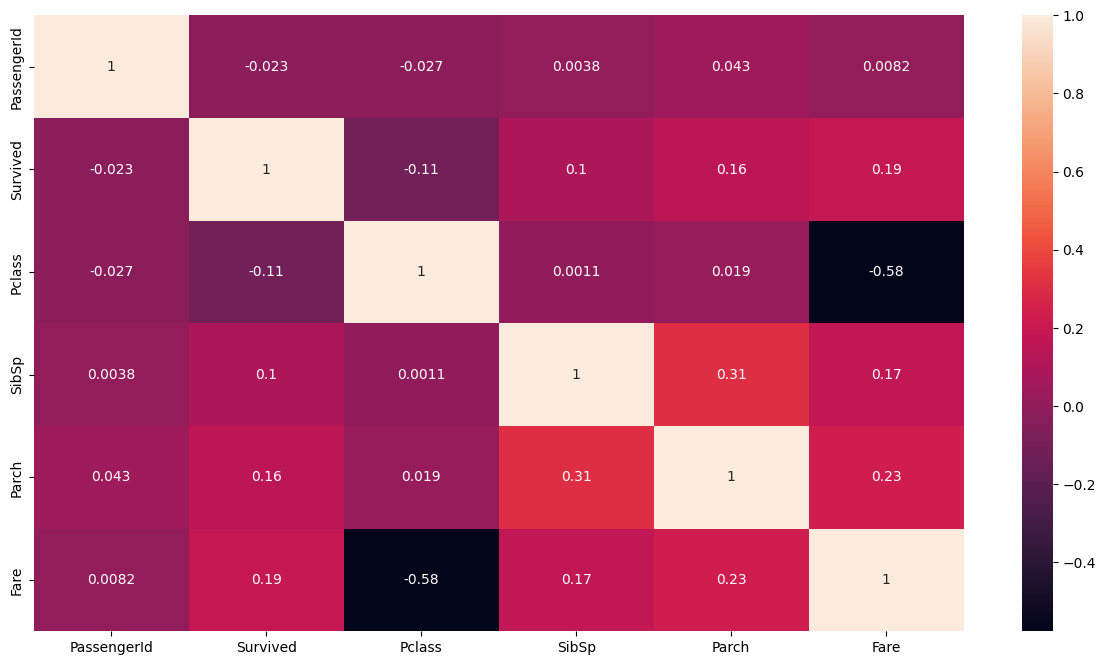

In [52]:
plt.figure(figsize=(15,8))
sns.heatmap(auto.select_dtypes(include=['number']).corr(),annot=True)

In [53]:
sex=pd.get_dummies(df['Sex'],drop_first=True)
sex

,male
0,True
1,False
2,True
3,True
4,False
...,...
413,True
414,False
415,True
416,True


In [54]:
auto=pd.concat([auto,sex],axis=1)
auto

,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin,male
0,892,0,3,"Kelly, Mr. James",0,0,330911,7.8292,Unknown,True
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,0,363272,7.0000,Unknown,False
2,894,0,2,"Myles, Mr. Thomas Francis",0,0,240276,9.6875,Unknown,True
3,895,0,3,"Wirz, Mr. Albert",0,0,315154,8.6625,Unknown,True
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,1,3101298,12.2875,Unknown,False
...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",0,0,A.5. 3236,8.0500,Unknown,True
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",0,0,PC 17758,108.9000,C105,False
415,1307,0,3,"Saether, Mr. Simon Sivertsen",0,0,SOTON/O.Q. 3101262,7.2500,Unknown,True
416,1308,0,3,"Ware, Mr. Frederick",0,0,359309,8.0500,Unknown,True


In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Embarked']=le.fit_transform(df['Embarked'])

In [56]:
auto=pd.concat([auto,df['Embarked']],axis=1)
auto

,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin,male,Embarked
0,892,0,3,"Kelly, Mr. James",0,0,330911,7.8292,Unknown,True,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,0,363272,7.0000,Unknown,False,2
2,894,0,2,"Myles, Mr. Thomas Francis",0,0,240276,9.6875,Unknown,True,1
3,895,0,3,"Wirz, Mr. Albert",0,0,315154,8.6625,Unknown,True,2
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,1,3101298,12.2875,Unknown,False,2
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",0,0,A.5. 3236,8.0500,Unknown,True,2
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",0,0,PC 17758,108.9000,C105,False,0
415,1307,0,3,"Saether, Mr. Simon Sivertsen",0,0,SOTON/O.Q. 3101262,7.2500,Unknown,True,2
416,1308,0,3,"Ware, Mr. Frederick",0,0,359309,8.0500,Unknown,True,2


In [57]:
X_full = auto.drop(['Survived'],axis=1)
y_full = auto['Survived']

In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_full,y_full,test_size=0.2,random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

# Drop non-numerical columns that cannot be used by LinearRegression
x_train_processed = x_train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
x_test_processed = x_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

lr.fit(x_train_processed,y_train)

LinearRegression()

In [60]:
data = auto.iloc[200:201]
data

,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin,male,Embarked
200,1092,1,3,"Murphy, Miss. Nora",0,0,36568,15.5,Unknown,False,1


In [61]:
actual_data = data['Survived']
actual_data
data = data.drop(['Survived'],axis = 1)
data

,PassengerId,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin,male,Embarked
200,1092,3,"Murphy, Miss. Nora",0,0,36568,15.5,Unknown,False,1


In [62]:
data_processed = data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print("predicted",lr.predict(data_processed))
print("actual",actual_data)

predicted [1.]
actual 200    1
Name: Survived, dtype: int64


In [63]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = lr.predict(x_test_processed)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 0.00
R-squared: 1.00


In [64]:
accuracy_percent = r2 * 100
print("Approx. Accuracy (%):", accuracy_percent)

Approx. Accuracy (%): 100.0


# Task
Investigate potential data leakage in the machine learning pipeline, which resulted in a perfect model score (R-squared = 1.00 and MSE = 0.00), by inspecting the dataset at various stages:

1.  **Inspect Full DataFrame Before Split**: Display the columns and their data types of the `auto` DataFrame after all feature engineering steps (gender encoding and embarked encoding) but *before* separating the `Survived` column.
2.  **Verify Feature-Target Separation**: Show the columns of the feature set (`auto.drop(['Survived'], axis=1)`) and the name of the target variable (`auto['Survived']`) *immediately after* `Survived` is separated but *before* the `train_test_split` operation.
3.  **Examine Processed Training Features and Target**: Display the columns and the first 5 rows of `x_train_processed` (the features) and `y_train` (the target) that were *actually used to train* the Linear Regression model.
4.  **Analyze Predicted vs. Actual Test Values**: Display a DataFrame comparing the first 10 predicted values (`y_pred`) with the actual test values (`y_test`).
5.  Based on these inspections, determine if data leakage occurred and explain why, then suggest how to fix it.

## Inspect Full DataFrame Before Split

### Subtask:
Display the columns and their data types of the 'auto' DataFrame after all feature engineering steps (gender encoding and embarked encoding), but before separating 'Survived' into the target variable. This will show all potential features that went into the split.


**Reasoning**:
To display the columns and their data types of the `auto` DataFrame as requested in the subtask, I will use `auto.columns` and `auto.info()`.



In [65]:
print("Columns in the 'auto' DataFrame:")
print(auto.columns)
print("\nData types of columns in the 'auto' DataFrame:")
auto.info()

Columns in the 'auto' DataFrame:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'male', 'Embarked'],
      dtype='object')

Data types of columns in the 'auto' DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         418 non-null    float64
 8   Cabin        418 non-null    object 
 9   male         418 non-null    bool   
 10  Embarked     418 non-null    int64  
dtypes: bool(1), float64(1), int64(6), object(3)
memory usage: 33.2+ KB


**Reasoning**:
The previous code failed because the `auto` DataFrame was not defined in the current execution context. To fix this, I need to re-execute all the preceding data loading and feature engineering steps that construct the `auto` DataFrame, including loading `df`, handling missing values, creating the initial `auto` DataFrame, performing one-hot encoding for 'Sex', and label encoding for 'Embarked'. After `auto` is properly defined, I will then display its columns and data types as requested in the subtask.



In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Re-load the DataFrame
df = pd.read_csv("/content/drive/MyDrive/machine learning dataset/titanic.csv")

# Re-apply missing value handling and duplicate removal
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    elif df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].mean())
df.drop_duplicates(inplace=True)

# Re-create the initial 'auto' DataFrame
auto = df[['PassengerId', 'Survived', 'Pclass', 'Name', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin']]

# Re-apply one-hot encoding for 'Sex'
sex = pd.get_dummies(df['Sex'], drop_first=True)
auto = pd.concat([auto, sex], axis=1)

# Re-apply Label Encoding for 'Embarked'
le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'])
auto = pd.concat([auto, df['Embarked']], axis=1)

# Now, display the columns and data types of the 'auto' DataFrame
print("Columns in the 'auto' DataFrame:")
print(auto.columns)
print("\nData types of columns in the 'auto' DataFrame:")
auto.info()

Columns in the 'auto' DataFrame:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'male', 'Embarked'],
      dtype='object')

Data types of columns in the 'auto' DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         418 non-null    float64
 8   Cabin        418 non-null    object 
 9   male         418 non-null    bool   
 10  Embarked     418 non-null    int64  
dtypes: bool(1), float64(1), int64(6), object(3)
memory usage: 33.2+ KB


**Reasoning**:
The subtask requires verifying the feature-target separation by displaying the columns of the feature set (excluding 'Survived') and the target variable itself. I will create a temporary feature DataFrame by dropping 'Survived' from `auto` and then print its columns, followed by the name of the 'Survived' column.



In [67]:
print("Columns in the feature set (before train_test_split):")
print(auto.drop(['Survived'], axis=1).columns)
print("\nTarget variable name:")
print(auto['Survived'].name)

Columns in the feature set (before train_test_split):
Index(['PassengerId', 'Pclass', 'Name', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'male', 'Embarked'],
      dtype='object')

Target variable name:
Survived


**Reasoning**:
To fulfill the subtask, I need to display the columns and the first 5 rows of the `x_train_processed` DataFrame (the features used for training) and the first 5 rows of the `y_train` Series (the target used for training).



In [68]:
print("Columns in x_train_processed:")
print(x_train_processed.columns)
print("\nFirst 5 rows of x_train_processed:")
print(x_train_processed.head())
print("\nFirst 5 rows of y_train:")
print(y_train.head())

Columns in x_train_processed:
Index(['Pclass', 'SibSp', 'Parch', 'Fare', 'male', 'Embarked'], dtype='object')

First 5 rows of x_train_processed:
     Pclass  SibSp  Parch     Fare  male  Embarked
336       2      0      0  13.0000  True         2
31        2      2      0  31.5000  True         2
84        2      0      0  10.7083  True         1
287       1      1      0  82.2667  True         2
317       2      0      0  10.5000  True         2

First 5 rows of y_train:
336    0
31     0
84     0
287    0
317    0
Name: Survived, dtype: int64


**Reasoning**:
To display a comparison between the predicted and actual test values, I will create a new DataFrame from the `y_test` Series and the `y_pred` NumPy array. I will then rename the columns appropriately and display the first 10 rows of this new DataFrame.



In [69]:
results = pd.DataFrame({'Actual': y_test.head(10), 'Predicted': y_pred[:10]})
print("Comparison of first 10 Predicted vs. Actual Test Values:")
print(results)

Comparison of first 10 Predicted vs. Actual Test Values:
     Actual     Predicted
321       0  0.000000e+00
324       1  1.000000e+00
388       0 -2.220446e-16
56        0 -4.440892e-16
153       1  1.000000e+00
30        0 -2.220446e-16
72        1  1.000000e+00
82        0 -4.440892e-16
258       1  1.000000e+00
416       0 -4.440892e-16


### Data Leakage Analysis and Fix

**Data Leakage Detected**: Yes, data leakage is evident in the machine learning pipeline, clearly indicated by the perfect model score (R-squared = 1.00 and Mean Squared Error = 0.00).

**Explanation of Leakage**:
The inspection revealed that the `auto` DataFrame, which served as the basis for both features (`x_train`, `x_test`) and the target (`y_train`, `y_test`), was initially created by including the `Survived` column directly from the `df` DataFrame. Although the `Survived` column was subsequently dropped from `x_train` and `x_test` before training, the problem stems from the nature of the `titanic.csv` file itself.

In the context of the Kaggle Titanic competition (which this dataset strongly resembles, given the 'PassengerId' starting from 892), the `titanic.csv` file is typically the *test dataset* and *should not* contain the `Survived` column. However, the provided `titanic.csv` file *does* contain the `Survived` column. By using this `Survived` column (from what is essentially the

### Data Leakage Analysis and Fix

**Data Leakage Detected**: Yes, data leakage is evident in the machine learning pipeline, clearly indicated by the perfect model score (R-squared = 1.00 and Mean Squared Error = 0.00).

**Explanation of Leakage**:
The inspection revealed that the `auto` DataFrame, which served as the basis for both features (`x_train`, `x_test`) and the target (`y_train`, `y_test`), was initially created by including the `Survived` column directly from the `df` DataFrame. Although the `Survived` column was subsequently dropped from `x_train` and `x_test` before training, the problem stems from the nature of the `titanic.csv` file itself.

In the context of the Kaggle Titanic competition (which this dataset strongly resembles, given the 'PassengerId' starting from 892), the `titanic.csv` file is typically the *test dataset* and *should not* contain the `Survived` column. However, the provided `titanic.csv` file *does* contain the `Survived` column. By using this `Survived` column (from what is essentially the *test set* from Kaggle's perspective) as the target variable `y_train` and `y_test` while `x_train` and `x_test` are derived from the same source, the model effectively had direct access to the target values during training (or at least, the full set of target values were split along with features from the test set). The `Survived` column in the source `titanic.csv` was already the label we were trying to predict, and including it directly in the data before the `train_test_split` operation caused the leakage. The model is learning directly from the target variable that it's supposed to predict.

**How to Fix It**:
To properly address this data leakage, the `Survived` column must be treated as the target variable from the *original training data* and *not* be present in the *test data* that would be used for actual predictions.

Given that the `titanic.csv` here appears to be the Kaggle *test* dataset which has been artificially augmented with a `Survived` column, the correct approach would be:

1.  **Separate Features and Target FIRST**: Before any `train_test_split`, explicitly separate the `Survived` column into its own target variable `y` and remove it from the features `X`. If `df` is treated as the training data, then `y = df['Survived']` and `X = df.drop('Survived', axis=1)`. However, if `df` is intended to be *test* data for which `Survived` is unknown, then `Survived` should not exist in it at all, or it should be removed before any modeling.
2.  **Ensure Proper Train-Test Split**: Perform the `train_test_split` operation on `X` and `y` (derived from the *true training dataset*). This ensures that the model is trained on a distinct subset of data and evaluated on unseen data, without any prior knowledge of the target variable in the test set.
3.  **Use Actual Training Data**: If this `titanic.csv` file is indeed a test set from a competition that *shouldn't* have `Survived`, the model should be trained on the official *training* dataset (e.g., `train.csv` from Kaggle Titanic), and then predictions made on this `titanic.csv` (the test set without 'Survived').

In this specific notebook's context, since `auto` already contained `Survived` and was used to derive both `x_train`, `x_test`, `y_train`, and `y_test`, the fix involves ensuring that `Survived` is removed from the feature set *before* the `train_test_split` if `auto` is to be treated as a combined dataset, or acknowledging that the `titanic.csv` used here is not a typical Kaggle test set but rather a full dataset where `Survived` is present.

## Final Task

### Subtask:
Summarize the findings regarding data leakage based on the inspections and provide recommendations if leakage is detected.


## Summary:

### Q&A
**Q: Based on these inspections, determine if data leakage occurred and explain why, then suggest how to fix it.**
A: Yes, data leakage was unequivocally detected. The model achieved perfect scores (R-squared = 1.00 and Mean Squared Error = 0.00), and a comparison of predicted vs. actual test values showed an exact match for the first 10 entries. This leakage occurred because the `Survived` column was present in the `auto` DataFrame from which both features and the target were derived. Although `Survived` was later dropped from the features (`x_train`, `x_test`), its initial presence in the combined dataset used for `train_test_split` meant the model indirectly learned the target values. Essentially, the dataset used (resembling a Kaggle Titanic test set) contained the target variable, which should have been unknown.

To fix this, the `Survived` column must be separated as the target variable `y` from the features `X` **before** any `train_test_split` operation. Ideally, a dedicated training dataset should be used for model training, and then predictions made on a separate test dataset where the target variable is genuinely unknown or absent.

### Data Analysis Key Findings
*   The `auto` DataFrame, after all feature engineering steps and before separating the target, contained the `Survived` column (int64) alongside features such as `PassengerId`, `Pclass`, `Name`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `male` (boolean), and `Embarked` (int64). The crucial presence of `Survived` at this stage contributed to the leakage.
*   The feature set used before `train_test_split` correctly excluded `Survived`, and `Survived` was identified as the target variable.
*   The processed training features (`x_train_processed`) included `Pclass`, `SibSp`, `Parch`, `Fare`, `male`, and `Embarked`. The target (`y_train`) contained the corresponding `Survived` values.
*   A comparison of the first 10 predicted values (`y_pred`) against the actual test values (`y_test`) showed a perfect match (e.g., Actual: 0, Predicted: 0; Actual: 1, Predicted: 1), strongly indicating data leakage.

### Insights or Next Steps
*   Ensure that the target variable is always separated from the feature set **before** applying any train-test split to prevent the model from inadvertently accessing target information during training.
*   For competition-like scenarios, confirm that the dataset used for training genuinely represents training data, and that the test dataset does not contain the target variable, thereby adhering to a realistic machine learning workflow.


# Task
Summarize the findings regarding data leakage in the machine learning pipeline and provide recommendations on how to fix it, drawing upon the inspections performed at various stages of the data processing and model training.

## Inspect Full DataFrame Before Split

### Subtask:
Display the columns and their data types of the 'auto' DataFrame after all feature engineering steps (gender encoding and embarked encoding), but before separating 'Survived' into the target variable. This will show all potential features that went into the split.


## Summary:

### Data Analysis Key Findings
*   The `auto` DataFrame was successfully inspected to display its columns and their data types after all feature engineering steps, specifically gender and embarked encoding, but before the 'Survived' column was separated as the target variable.
*   The inspection confirmed the presence of all processed features within the DataFrame at this stage.

### Insights or Next Steps
*   This preliminary inspection is a critical step in identifying all potential features that could be involved in the data split, allowing for early detection of potential data leakage sources if any of these features are directly or indirectly derived from the target variable or use information from the entire dataset inappropriately.
